# Sentiment Analysis of IMDb Data (Movie Reviews)
This dataset comes from Kaggle: https://www.kaggle.com/datasets/krystalliu152/imbd-movie-reviewnpl.

It was previously downloaded and uploaded to a GitHub repository to make it much easier to run.

This dataset comes pre-transformed and contains two columns: `sentiment` and `review`. It focuses on binary classification analysis, making it ideal for linear models.

The project will consist of several parts, broken down into different code blocks so that each step can be followed in a more interactive way.

# Data Cleaning
Before working with the data, we need to normalize it so the model can understand the information we are providing. If the input data is not appropriate, a series of errors will be triggered, so it is essential to verify that the data is in the best possible shape.
# Visualization
We will represent the data graphically so that we can detect frequencies, trends, and feature patterns, since it is difficult to interpret the data explicitly and much easier to visualize it to plan a strategy for the project.
# Modeling
We will move on to the modeling stage, where different models are tested to find which one best fits the data and achieves the best performance — leaving nothing to chance and obtaining the best possible metric results.
# Model Implementation
We will look for the utility of the algorithm: what benefit it provides and what problem it can solve. We will also outline its limitations, propose steps for improvement, draw conclusions based on the project results, and discuss how the model contributes to society.

# Data Import
First and foremost, we need to have the data available. The dataset was previously uploaded to a GitHub repository.


In [1]:
import pandas as pd

# Import the dataset previously uploaded to GitHub to facilitate reproducibility
df = pd.read_csv("https://raw.githubusercontent.com/laurenBack98/Data_set_sentiments_2/refs/heads/main/Review.csv")

# Display the first 10 rows
df.head(10)


,sentiment,review
0,Negative,I had no background knowledge of this movie be...
1,Negative,I am a huge Jane Austen fan and I ordered the ...
2,Negative,Nothing to say but Wow! Has anyone actually ha...
3,Negative,i like Jane Austin novels. I love Pride and Pr...
4,Negative,In this day and age of incredible special movi...
5,Negative,Becky Harris plays the female shopper whose mi...
6,Negative,Watching TRUTH ABOUT LOVE (is this a double en...
7,Negative,"A painfully protracted, maudlin and predictabl..."
8,Negative,"Let's be honest. As a film school project, mad..."
9,Negative,A terrible movie as everyone has said. What ma...


# Dataset Information
Visualizing the data before starting to work with it is important. Many problems are detected early thanks to these good practices, since we can check for missing data, imbalanced features, or any other detail that could bias the model's results.


* `df.isnull().sum()` ===> Detects NaN or null values in the dataset columns. Very useful for knowing upfront what strategy to use to fill in missing data.


In [2]:
# This line checks whether the dataset contains missing or NaN values
# that could affect our analysis later on
df.isnull().sum()


,0
sentiment,0
review,0


* `df.info()` ===> Provides even more information about the columns, such as their data types and whether those columns have missing values.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  10000 non-null  object
 1   review     10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


* `df['column'].value_counts()` ===> Mainly used to check whether classes are imbalanced or not.

As shown below, the classes are fairly balanced, so we do not need to worry about the model learning more from one class than the other, since it will have almost the same amount of data for training and testing.


In [4]:
df['sentiment'].value_counts()

,count
sentiment,
Negative,5081
Positive,4919


# Regex
To normalize the data we will use the `re` (regex) library, which allows us to identify character patterns and either remove or replace them depending on the desired functionality.


In [5]:
import re  # regex

def clean_text(text):
  # This line ensures that text blocks do not contain special characters,
  # numbers, or anything else that could affect the models
  text = re.sub(r'[^a-zA-Z]', ' ', text)
  text = re.sub(r'[()]', ' ', text)
  text = re.sub(r'\s', ' ', text)
  # Added lower() to return the text in lowercase
  return text.lower()


# Feature Engineering
Once we have ensured that the data is complete and ready to be processed, we can get a better overview and decide which strategies to use so that the ML or Deep Learning models receive the best possible data quality.


In [6]:
# We make a copy of the data as a good practice
# that can save us from issues in the future or if we need to roll back
df_cln = df.copy()

# Apply the clean_text function using .apply() to normalize the text
df_cln['review_clean'] = df_cln['review'].apply(lambda x: clean_text(x))
df_cln.head(15)


,sentiment,review,review_clean
0,Negative,I had no background knowledge of this movie be...,i had no background knowledge of this movie be...
1,Negative,I am a huge Jane Austen fan and I ordered the ...,i am a huge jane austen fan and i ordered the ...
2,Negative,Nothing to say but Wow! Has anyone actually ha...,nothing to say but wow has anyone actually ha...
3,Negative,i like Jane Austin novels. I love Pride and Pr...,i like jane austin novels i love pride and pr...
4,Negative,In this day and age of incredible special movi...,in this day and age of incredible special movi...
5,Negative,Becky Harris plays the female shopper whose mi...,becky harris plays the female shopper whose mi...
6,Negative,Watching TRUTH ABOUT LOVE (is this a double en...,watching truth about love is this a double en...
7,Negative,"A painfully protracted, maudlin and predictabl...",a painfully protracted maudlin and predictabl...
8,Negative,"Let's be honest. As a film school project, mad...",let s be honest as a film school project mad...
9,Negative,A terrible movie as everyone has said. What ma...,a terrible movie as everyone has said what ma...


In [7]:
df_cln['sentiment_map'] = df_cln['sentiment'].map({ 'Positive': 1 ,'Negative': 0 })
df_cln.head(15)

,sentiment,review,review_clean,sentiment_map
0,Negative,I had no background knowledge of this movie be...,i had no background knowledge of this movie be...,0
1,Negative,I am a huge Jane Austen fan and I ordered the ...,i am a huge jane austen fan and i ordered the ...,0
2,Negative,Nothing to say but Wow! Has anyone actually ha...,nothing to say but wow has anyone actually ha...,0
3,Negative,i like Jane Austin novels. I love Pride and Pr...,i like jane austin novels i love pride and pr...,0
4,Negative,In this day and age of incredible special movi...,in this day and age of incredible special movi...,0
5,Negative,Becky Harris plays the female shopper whose mi...,becky harris plays the female shopper whose mi...,0
6,Negative,Watching TRUTH ABOUT LOVE (is this a double en...,watching truth about love is this a double en...,0
7,Negative,"A painfully protracted, maudlin and predictabl...",a painfully protracted maudlin and predictabl...,0
8,Negative,"Let's be honest. As a film school project, mad...",let s be honest as a film school project mad...,0
9,Negative,A terrible movie as everyone has said. What ma...,a terrible movie as everyone has said what ma...,0


In [8]:
df_negative = df_cln[df_cln['sentiment'] == 'Negative']
df_negative.head(15)

,sentiment,review,review_clean,sentiment_map
0,Negative,I had no background knowledge of this movie be...,i had no background knowledge of this movie be...,0
1,Negative,I am a huge Jane Austen fan and I ordered the ...,i am a huge jane austen fan and i ordered the ...,0
2,Negative,Nothing to say but Wow! Has anyone actually ha...,nothing to say but wow has anyone actually ha...,0
3,Negative,i like Jane Austin novels. I love Pride and Pr...,i like jane austin novels i love pride and pr...,0
4,Negative,In this day and age of incredible special movi...,in this day and age of incredible special movi...,0
5,Negative,Becky Harris plays the female shopper whose mi...,becky harris plays the female shopper whose mi...,0
6,Negative,Watching TRUTH ABOUT LOVE (is this a double en...,watching truth about love is this a double en...,0
7,Negative,"A painfully protracted, maudlin and predictabl...",a painfully protracted maudlin and predictabl...,0
8,Negative,"Let's be honest. As a film school project, mad...",let s be honest as a film school project mad...,0
9,Negative,A terrible movie as everyone has said. What ma...,a terrible movie as everyone has said what ma...,0


In [9]:
df_positive = df_cln[df_cln['sentiment'] == 'Positive']
df_positive.head(15)

,sentiment,review,review_clean,sentiment_map
5081,Positive,I would have rated the series a perfect 10 for...,i would have rated the series a perfect for...,1
5082,Positive,Greetings again from the darkness. Insight int...,greetings again from the darkness insight int...,1
5083,Positive,I went to a small advance screening of this mo...,i went to a small advance screening of this mo...,1
5084,Positive,'Holes' is my all-time favorite movie! So far ...,holes is my all time favorite movie so far ...,1
5085,Positive,It really is a shame that films like this neve...,it really is a shame that films like this neve...,1
5086,Positive,"Somehow, this movie manages to be invigorating...",somehow this movie manages to be invigorating...,1
5087,Positive,These guys are anything but the Usual Suspects...,these guys are anything but the usual suspects...,1
5088,Positive,"After CITIZEN KANE in 1941, Hollywood executiv...",after citizen kane in hollywood executiv...,1
5089,Positive,Why on earth should you explore the mesmerizin...,why on earth should you explore the mesmerizin...,1
5090,Positive,This is another gem of a stand up show from Ed...,this is another gem of a stand up show from ed...,1


# NLP with NLTK


In [10]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [11]:
# Copy the data
df_nltk = df_cln.copy()
# Tokenize the reviews
df_nltk['review_tokenized'] = df_nltk['review_clean'].apply(lambda x: word_tokenize(x))
# Display
df_nltk.head(15)


,sentiment,review,review_clean,sentiment_map,review_tokenized
0,Negative,I had no background knowledge of this movie be...,i had no background knowledge of this movie be...,0,"[i, had, no, background, knowledge, of, this, ..."
1,Negative,I am a huge Jane Austen fan and I ordered the ...,i am a huge jane austen fan and i ordered the ...,0,"[i, am, a, huge, jane, austen, fan, and, i, or..."
2,Negative,Nothing to say but Wow! Has anyone actually ha...,nothing to say but wow has anyone actually ha...,0,"[nothing, to, say, but, wow, has, anyone, actu..."
3,Negative,i like Jane Austin novels. I love Pride and Pr...,i like jane austin novels i love pride and pr...,0,"[i, like, jane, austin, novels, i, love, pride..."
4,Negative,In this day and age of incredible special movi...,in this day and age of incredible special movi...,0,"[in, this, day, and, age, of, incredible, spec..."
5,Negative,Becky Harris plays the female shopper whose mi...,becky harris plays the female shopper whose mi...,0,"[becky, harris, plays, the, female, shopper, w..."
6,Negative,Watching TRUTH ABOUT LOVE (is this a double en...,watching truth about love is this a double en...,0,"[watching, truth, about, love, is, this, a, do..."
7,Negative,"A painfully protracted, maudlin and predictabl...",a painfully protracted maudlin and predictabl...,0,"[a, painfully, protracted, maudlin, and, predi..."
8,Negative,"Let's be honest. As a film school project, mad...",let s be honest as a film school project mad...,0,"[let, s, be, honest, as, a, film, school, proj..."
9,Negative,A terrible movie as everyone has said. What ma...,a terrible movie as everyone has said what ma...,0,"[a, terrible, movie, as, everyone, has, said, ..."


In [12]:
# Keep only the most relevant information for the model
df_nltk_model = df_nltk.drop(columns=['review', 'sentiment', 'review_clean'])
# Display
df_nltk_model.head(15)


,sentiment_map,review_tokenized
0,0,"[i, had, no, background, knowledge, of, this, ..."
1,0,"[i, am, a, huge, jane, austen, fan, and, i, or..."
2,0,"[nothing, to, say, but, wow, has, anyone, actu..."
3,0,"[i, like, jane, austin, novels, i, love, pride..."
4,0,"[in, this, day, and, age, of, incredible, spec..."
5,0,"[becky, harris, plays, the, female, shopper, w..."
6,0,"[watching, truth, about, love, is, this, a, do..."
7,0,"[a, painfully, protracted, maudlin, and, predi..."
8,0,"[let, s, be, honest, as, a, film, school, proj..."
9,0,"[a, terrible, movie, as, everyone, has, said, ..."


In [13]:
# English stopwords list
stop_w = set(stopwords.words('english'))


In [14]:
# Apply a loop that removes stopwords from the reviews
df_nltk_model['review_stopwords'] = df_nltk_model['review_tokenized'].apply(lambda tokens: [word for word in tokens if word not in stop_w])
# Display
df_nltk_model.head(15)


,sentiment_map,review_tokenized,review_stopwords
0,0,"[i, had, no, background, knowledge, of, this, ...","[background, knowledge, movie, bought, sounded..."
1,0,"[i, am, a, huge, jane, austen, fan, and, i, or...","[huge, jane, austen, fan, ordered, movie, amaz..."
2,0,"[nothing, to, say, but, wow, has, anyone, actu...","[nothing, say, wow, anyone, actually, somebody..."
3,0,"[i, like, jane, austin, novels, i, love, pride...","[like, jane, austin, novels, love, pride, prej..."
4,0,"[in, this, day, and, age, of, incredible, spec...","[day, age, incredible, special, movie, effects..."
5,0,"[becky, harris, plays, the, female, shopper, w...","[becky, harris, plays, female, shopper, whose,..."
6,0,"[watching, truth, about, love, is, this, a, do...","[watching, truth, love, double, entendre, star..."
7,0,"[a, painfully, protracted, maudlin, and, predi...","[painfully, protracted, maudlin, predictable, ..."
8,0,"[let, s, be, honest, as, a, film, school, proj...","[let, honest, film, school, project, made, wit..."
9,0,"[a, terrible, movie, as, everyone, has, said, ...","[terrible, movie, everyone, said, made, laugh,..."


In [15]:
# Lemmatize the reviews
df_nltk_model['review_lematizer'] = df_nltk_model['review_stopwords'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])
# Display
df_nltk_model.head(15)


,sentiment_map,review_tokenized,review_stopwords,review_lematizer
0,0,"[i, had, no, background, knowledge, of, this, ...","[background, knowledge, movie, bought, sounded...","[background, knowledge, movie, bought, sounded..."
1,0,"[i, am, a, huge, jane, austen, fan, and, i, or...","[huge, jane, austen, fan, ordered, movie, amaz...","[huge, jane, austen, fan, ordered, movie, amaz..."
2,0,"[nothing, to, say, but, wow, has, anyone, actu...","[nothing, say, wow, anyone, actually, somebody...","[nothing, say, wow, anyone, actually, somebody..."
3,0,"[i, like, jane, austin, novels, i, love, pride...","[like, jane, austin, novels, love, pride, prej...","[like, jane, austin, novel, love, pride, preju..."
4,0,"[in, this, day, and, age, of, incredible, spec...","[day, age, incredible, special, movie, effects...","[day, age, incredible, special, movie, effect,..."
5,0,"[becky, harris, plays, the, female, shopper, w...","[becky, harris, plays, female, shopper, whose,...","[becky, harris, play, female, shopper, whose, ..."
6,0,"[watching, truth, about, love, is, this, a, do...","[watching, truth, love, double, entendre, star...","[watching, truth, love, double, entendre, star..."
7,0,"[a, painfully, protracted, maudlin, and, predi...","[painfully, protracted, maudlin, predictable, ...","[painfully, protracted, maudlin, predictable, ..."
8,0,"[let, s, be, honest, as, a, film, school, proj...","[let, honest, film, school, project, made, wit...","[let, honest, film, school, project, made, wit..."
9,0,"[a, terrible, movie, as, everyone, has, said, ...","[terrible, movie, everyone, said, made, laugh,...","[terrible, movie, everyone, said, made, laugh,..."


In [16]:
# Keep only the columns of interest
df_nltk_final = df_nltk_model.drop(columns=['review_tokenized', 'review_stopwords'])
# Display
df_nltk_final.head(15)


,sentiment_map,review_lematizer
0,0,"[background, knowledge, movie, bought, sounded..."
1,0,"[huge, jane, austen, fan, ordered, movie, amaz..."
2,0,"[nothing, say, wow, anyone, actually, somebody..."
3,0,"[like, jane, austin, novel, love, pride, preju..."
4,0,"[day, age, incredible, special, movie, effect,..."
5,0,"[becky, harris, play, female, shopper, whose, ..."
6,0,"[watching, truth, love, double, entendre, star..."
7,0,"[painfully, protracted, maudlin, predictable, ..."
8,0,"[let, honest, film, school, project, made, wit..."
9,0,"[terrible, movie, everyone, said, made, laugh,..."


# WordCloud — Word Clouds
To start analyzing the word distribution in the dataset, we use word clouds — both overall and by separating positive reviews from negative ones — with the goal of identifying which patterns can be found in each class.


In [17]:
# importamos WordCloud
from wordcloud import WordCloud
# importamos matplotlib
import matplotlib.pyplot as plt

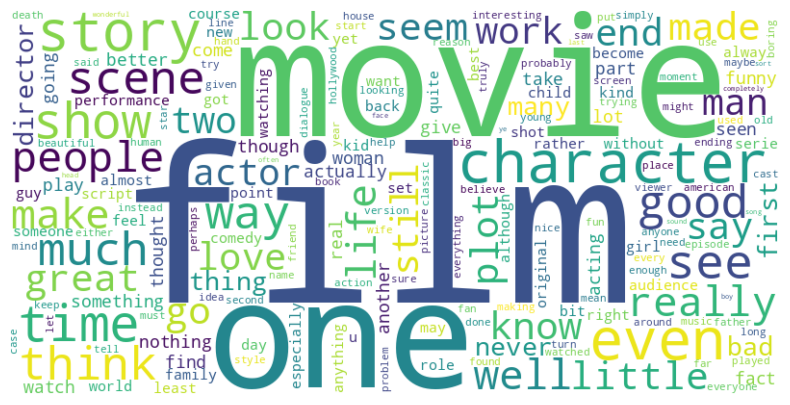

In [18]:
# General visualization
# We create a new column with strings separated by spaces,
# simulating text chains
df_nltk_final['review_lematizer_str'] = df_nltk_final['review_lematizer'].apply(lambda x: " ".join(x))
text = " ".join(df_nltk_final['review_lematizer_str'])

# Instantiate WordCloud with the most relevant parameters
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


* # WordCloud — Positive Reviews


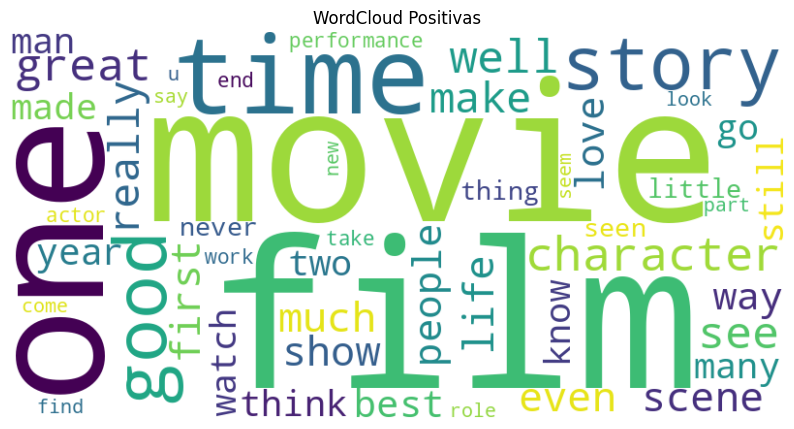

In [19]:
# Filter out negative reviews to keep only the positive ones
df_pos = df_nltk_final[df_nltk_final['sentiment_map'] == 1]
# New variable with strings separated by spaces
text_post = " ".join(df_pos['review_lematizer_str'])
# Instantiate wordcloud
wordcloud_pos = WordCloud(width=800, height=400, collocations=False, max_words=50, background_color='white').generate(text_post)
# Plot
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('WordCloud - Positive Reviews')
plt.axis('off')
plt.show()


* # WordCloud — Negative Reviews


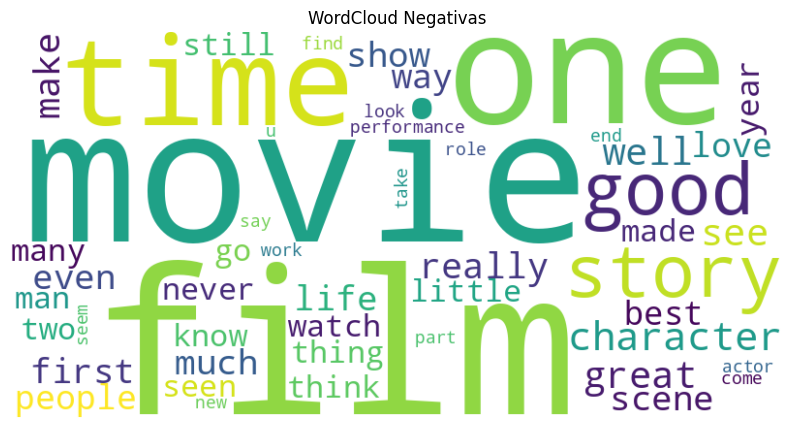

In [20]:
# Filter positive reviews to keep only the negative ones
df_neg = df_nltk_final[df_nltk_final['sentiment_map'] == 0]
# New variable with strings separated by spaces
text_neg = " ".join(df_pos['review_lematizer_str'])
# Instantiate wordcloud
wordcloud_neg = WordCloud(width=800, height=400, collocations=False, max_words=50, background_color='white').generate(text_neg)
# Plot
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('WordCloud - Negative Reviews')
plt.axis('off')
plt.show()


As we can observe in the word clouds, the most prominent terms at a glance are the same in both positive and negative reviews. Words like "movie", "film", and "one" are the most repeated. This tells us that vocabulary alone is not enough to determine the sentiment of a review — it is the combination and order of words that provides the key.


* # N-Grams
To take it a step further, we will create 3-gram n-grams to see if the findings make more sense and allow us to reach a conclusion.


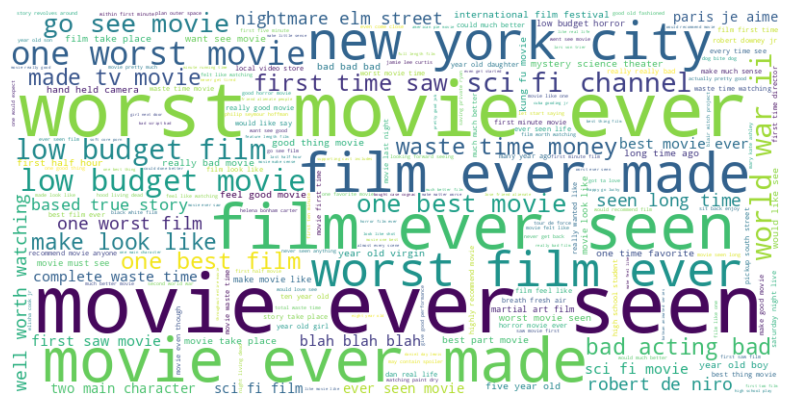

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Crear el CountVectorizer con las stopwords definidas
vectorizer = CountVectorizer(ngram_range=(3,3), stop_words = list(stop_w))

# Transformar el texto de la columna 'review_lematizer_str' en n-gramas
X = vectorizer.fit_transform(df_nltk_final['review_lematizer_str'])

# Extraer los n-gramas y sus frecuencias
n_grams = vectorizer.get_feature_names_out()
frequencies = X.toarray().sum(axis=0)

# Crear un diccionario con los n-gramas y sus frecuencias
n_grams_freq = dict(zip(n_grams, frequencies))

# Generar la WordCloud desde las frecuencias de los n-gramas
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(n_grams_freq)

# Mostrar la WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In this case the result is very different. The most frequent N-Grams are "worst movie ever", "film ever seen", and "movie ever made". Unlike the other word clouds, here we can detect a clear pattern of negative sentiment, where the word "worst" stands out as the protagonist. This demonstrates that n-grams can capture some patterns, but not clearly enough to draw a solid conclusion from the data as a whole.


* # N-Grams — Positive


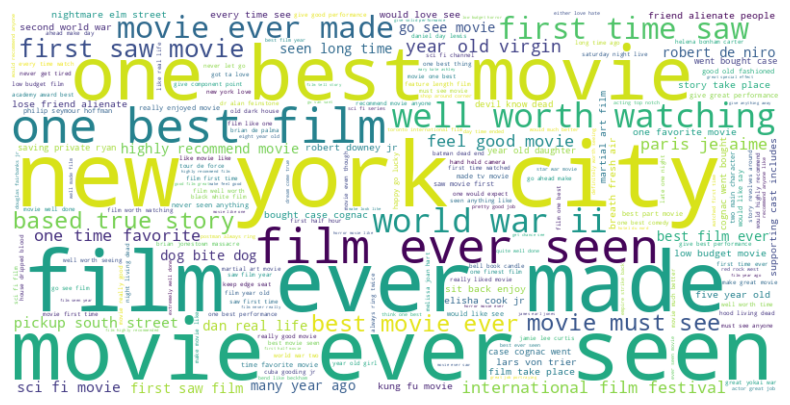

In [22]:
df_posi_ngram = df_nltk_final[df_nltk_final['sentiment_map'] == 1]
# Crear el CountVectorizer con las stopwords definidas
vectorizer = CountVectorizer(ngram_range=(3,3), stop_words = list(stop_w))

# Transformar el texto de la columna 'review_lematizer_str' en n-gramas
X = vectorizer.fit_transform(df_posi_ngram['review_lematizer_str'])

# Extraer los n-gramas y sus frecuencias
n_grams = vectorizer.get_feature_names_out()
frequencies = X.toarray().sum(axis=0)

# Crear un diccionario con los n-gramas y sus frecuencias
n_grams_freq = dict(zip(n_grams, frequencies))

# Generar la WordCloud desde las frecuencias de los n-gramas
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(n_grams_freq)

# Mostrar la WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

We can notice that the 3 most frequent N-Grams are "new york city", "film ever made", and "movie ever seen". These are part of the cinematic vocabulary, which makes it very difficult to detect a clear pattern indicating positive sentiment.


* # N-Grams — Negative


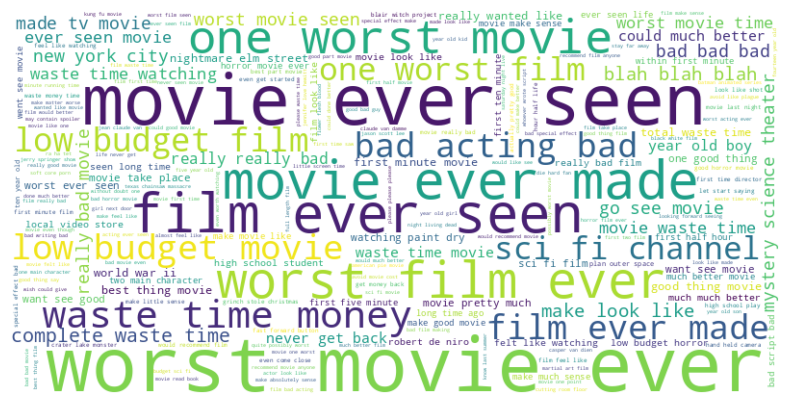

In [23]:
df_neg_ngram = df_nltk_final[df_nltk_final['sentiment_map'] == 0]
# Crear el CountVectorizer con las stopwords definidas
vectorizer = CountVectorizer(ngram_range=(3,3), stop_words = list(stop_w))

# Transformar el texto de la columna 'review_lematizer_str' en n-gramas
X = vectorizer.fit_transform(df_neg_ngram['review_lematizer_str'])

# Extraer los n-gramas y sus frecuencias
n_grams = vectorizer.get_feature_names_out()
frequencies = X.toarray().sum(axis=0)

# Crear un diccionario con los n-gramas y sus frecuencias
n_grams_freq = dict(zip(n_grams, frequencies))

# Generar la WordCloud desde las frecuencias de los n-gramas
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(n_grams_freq)

# Mostrar la WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Top 10 Most Frequent Words (Positive vs. Negative)
To further explore the previous analysis, let's look at the 10 most used words in the reviews overall, and then break them down by positive and negative reviews to see if we can detect any relevant pattern.


In [24]:
# Import collections to get word frequency
from collections import Counter

# List comprehension loop
# Used to count word frequency
tokens_lematizados = [token for token_list in df_nltk_final['review_lematizer'] for token in token_list]
# Use Counter to get frequency
frecuencia_tokens = Counter(tokens_lematizados)
# Show the top 10 most used words
frecuencia_tokens.most_common(10)


[('movie', 20461),
 ('film', 18524),
 ('one', 11155),
 ('like', 8230),
 ('time', 6312),
 ('good', 5934),
 ('character', 5664),
 ('story', 5336),
 ('even', 5073),
 ('get', 5028)]

* # Visualization with Matplotlib

Once we have the frequency of each word, the next step is to visualize it. For this we use Matplotlib as our main tool, which will help us identify differences between positive and negative reviews, if any exist.



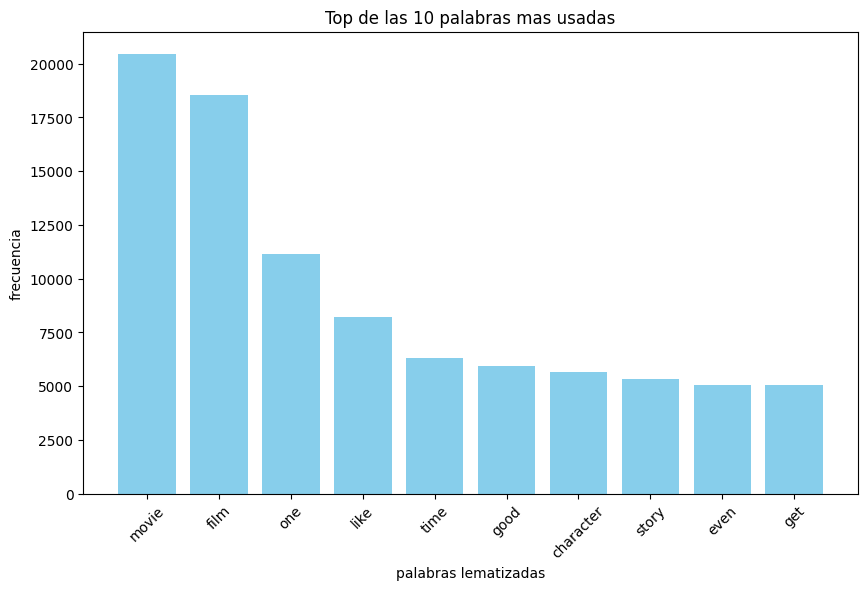

In [25]:
# Import matplotlib
import matplotlib.pyplot as plt
# Split tuples into 2 variables:
# palabras_lem stores each string
# frecuencia_lem stores how many times each string appears
palabras_lem, frecuencia_lem = zip(*frecuencia_tokens.most_common(10))
# Plot with matplotlib
plt.figure(figsize=(10, 6))
plt.bar(palabras_lem, frecuencia_lem, color='skyblue')
plt.xlabel('Lemmatized words')
plt.ylabel('Frequency')
plt.title('Top 10 Most Used Words')
plt.xticks(rotation=45)
plt.show()


We can see that "movie" is the most used string, followed by "film" and "one" in third place. With this information we can view word frequencies in a more user-friendly way. However, we still need to break them down by positive and negative frequency to see if any pattern emerges.


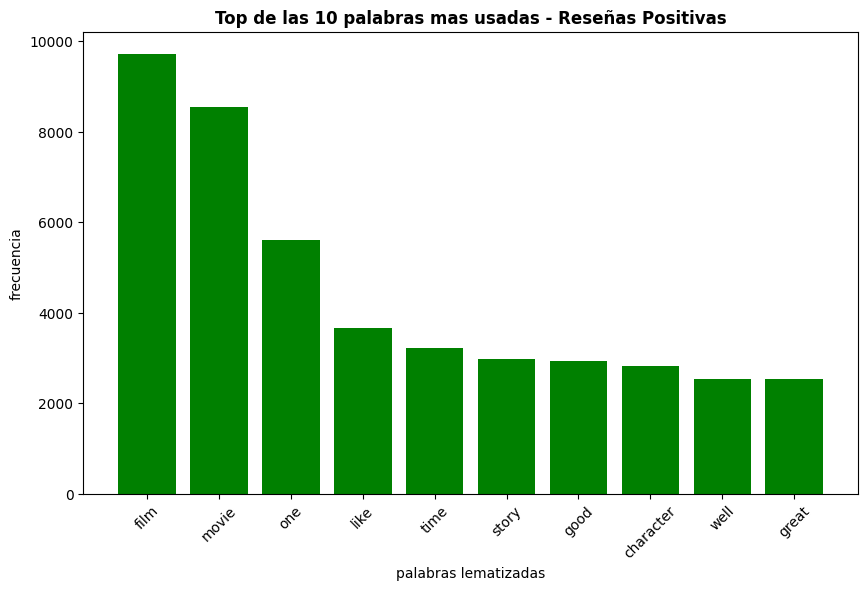

In [26]:
# Copy the data
df_posi_plot = df_nltk_final.copy()
# Positive dataframe
df_posi_plot = df_posi_plot[df_posi_plot['sentiment_map'] == 1]
# List comprehension loop
# Used to count word frequency
tokens_lematizados_pos = [token for token_list in df_posi_plot['review_lematizer'] for token in token_list]
# Use Counter to get frequency
frecuencia_tokens_pos = Counter(tokens_lematizados_pos)
# Split tuples into 2 variables
palabras_lem_pos, frecuencia_lem_pos = zip(*frecuencia_tokens_pos.most_common(10))
# Visualization
plt.figure(figsize=(10, 6))
plt.title('Top 10 Most Used Words - Positive Reviews', fontsize=12, fontweight='bold')
plt.bar(palabras_lem_pos, frecuencia_lem_pos, color='green')
plt.xlabel('Lemmatized words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


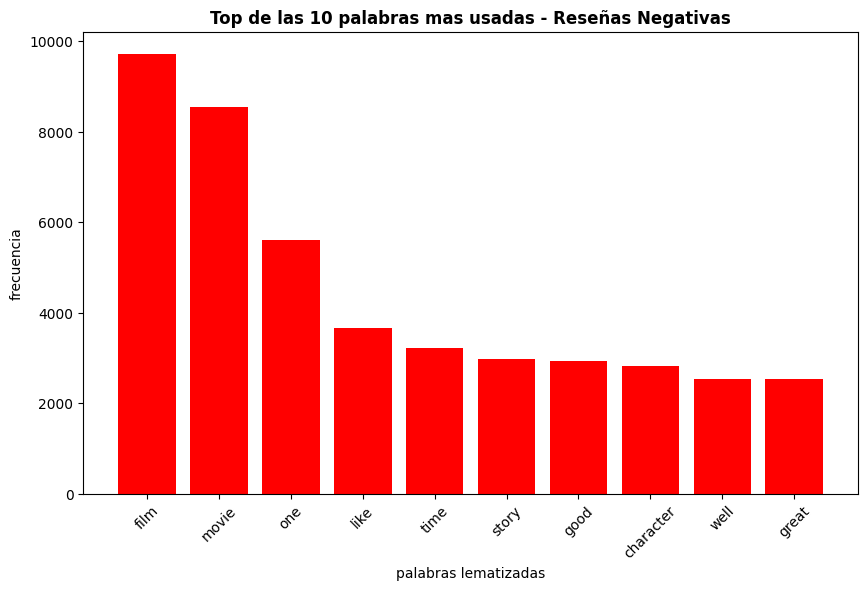

In [27]:
# Copy the data
df_neg_plot = df_nltk_final.copy()
# Negative dataframe
df_neg_plot = df_neg_plot[df_neg_plot['sentiment_map'] == 0]
# List comprehension loop
# Used to count word frequency
tokens_lematizados_neg = [token for token_list in df_posi_plot['review_lematizer'] for token in token_list]
# Use Counter to get frequency
frecuencia_tokens_neg = Counter(tokens_lematizados_neg)
# Split tuples into 2 variables
palabras_lem_neg, frecuencia_lem_neg = zip(*frecuencia_tokens_neg.most_common(10))
# Visualization
plt.figure(figsize=(10, 6))
plt.title('Top 10 Most Used Words - Negative Reviews', fontsize=12, fontweight='bold')
plt.bar(palabras_lem_neg, frecuencia_lem_neg, color='red')
plt.xlabel('Lemmatized words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


We observe that the most frequent words found in the dataset are neutral cinematic terms such as "movie", "film", "one", and others, which appear equally in both positive and negative reviews. This tells us that sentiment is not determined by a single word but by the combination and context of words — which is why it makes sense to use techniques like grammatical tagging with spaCy to retain higher semantic content, and more complex models like RNN, LSTM, or GRU that are capable of capturing word context.


# NLP with spaCy

Although spaCy could be used for tokenization, stopword removal, and lemmatization, in this project it will be used for Part-of-Speech (POS) Tagging, which helps us detect nouns, adjectives, and verbs.

This practice can further improve the quality of the processed data for the selected models, since we already have lemmatized text. By incorporating grammatical tagging, we can filter out only the words with the highest semantic content, such as nouns, adjectives, and verbs.


In [28]:
# Import spacy
import spacy
# Load spaCy with the grammatical model used in this case: 'en_core_web_sm'
nlp = spacy.load('en_core_web_sm')
# Add a list to later convert it into a dataframe
proces_nlp = []
# NLP processing loop
# Iterates over each review and converts it into an NLP object
# which makes it easy to filter stopwords
# 'ner' and 'parser' are disabled to speed up the process
# batch_size=500 sets the data processing batch size
for text in nlp.pipe(df_cln['review_clean'], disable=['ner', 'parser'], batch_size=500):
  # NLP object
  doc = nlp(text)
  # Each iteration appends a sentence that is already lemmatized,
  # free of stopwords and punctuation
  proces_nlp.append(' '.join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct]))


In [29]:
# Create the DataFrame
dt_1 = pd.DataFrame({'review_final': proces_nlp})
# Display
dt_1.head(15)


,review_final
0,background knowledge movie buy sound cool ve...
1,huge jane austen fan order movie amazon uk wai...
2,wow actually somebody sneak open field hap...
3,like jane austin novel love pride prejudice ...
4,day age incredible special movie effect sore...
5,becky harris play female shopper misfortune st...
6,watch truth love double entendre star lik...
7,painfully protract maudlin predictable drama...
8,let s honest film school project budget ...
9,terrible movie say laugh cameo appearance sc...


In [30]:
# Concatenate to see the differences
concat_df = pd.concat([df_cln, dt_1], axis=1)
# Display
concat_df.head(15)


,sentiment,review,review_clean,sentiment_map,review_final
0,Negative,I had no background knowledge of this movie be...,i had no background knowledge of this movie be...,0,background knowledge movie buy sound cool ve...
1,Negative,I am a huge Jane Austen fan and I ordered the ...,i am a huge jane austen fan and i ordered the ...,0,huge jane austen fan order movie amazon uk wai...
2,Negative,Nothing to say but Wow! Has anyone actually ha...,nothing to say but wow has anyone actually ha...,0,wow actually somebody sneak open field hap...
3,Negative,i like Jane Austin novels. I love Pride and Pr...,i like jane austin novels i love pride and pr...,0,like jane austin novel love pride prejudice ...
4,Negative,In this day and age of incredible special movi...,in this day and age of incredible special movi...,0,day age incredible special movie effect sore...
5,Negative,Becky Harris plays the female shopper whose mi...,becky harris plays the female shopper whose mi...,0,becky harris play female shopper misfortune st...
6,Negative,Watching TRUTH ABOUT LOVE (is this a double en...,watching truth about love is this a double en...,0,watch truth love double entendre star lik...
7,Negative,"A painfully protracted, maudlin and predictabl...",a painfully protracted maudlin and predictabl...,0,painfully protract maudlin predictable drama...
8,Negative,"Let's be honest. As a film school project, mad...",let s be honest as a film school project mad...,0,let s honest film school project budget ...
9,Negative,A terrible movie as everyone has said. What ma...,a terrible movie as everyone has said what ma...,0,terrible movie say laugh cameo appearance sc...


In [31]:
print(len(concat_df))

10000


# Semantic and Grammatical Analysis (POS Tagging)


* # POS Tagging Process
For these examples:


In [32]:
# Import displacy
# to see how it works
from spacy import displacy
# Take a small sample from the dataset — in this case review number 50
muestra_pos_tag = concat_df['review_final'].iloc[50]

# Plot
displacy.render(nlp(muestra_pos_tag), style='dep', jupyter=True, options={'compact': True, 'distance': 100})


We begin the POS tagging process, where we will filter out words that are not relevant for the selected models.


In [71]:
# List prepared to store results
pos_taggin = []
# Loop that iterates through all reviews in 'review_final' with spaCy
# batch_size=500 processes in batches
# enumerate() assigns a number to each review, used as review_id
for i, doc in enumerate(nlp.pipe(concat_df['review_final'], batch_size=500)):
    for token in doc:
        # Condition that filters stopwords, spaces, and
        # all characters that are not part of natural language
        if not token.is_stop and not token.is_punct and not token.is_space:
            # If the condition is met, append adds 3 columns:
            # an id column 'review_id', a column that holds tokens (words),
            # and a column with the respective grammatical tag
            pos_taggin.append({
                'review_id': i,
                'token': token.text,
                'pos_tag': token.pos_
            })
# Convert to DataFrame
df_pos_taggin = pd.DataFrame(pos_taggin)


In [34]:
# DISPLAY
df_pos_taggin.head(15)


,review_id,token,pos_tag
0,0,background,NOUN
1,0,knowledge,NOUN
2,0,movie,NOUN
3,0,buy,VERB
4,0,sound,NOUN
5,0,cool,ADJ
6,0,ve,AUX
7,0,want,VERB
8,0,kick,NOUN
9,0,butt,PROPN


To provide the models with the most relevant information, we will use the three categories with the highest semantic content: adjectives, verbs, and nouns. The remaining words that would only generate noise in the data will be discarded.


In [35]:
pos_tag_fil = df_pos_taggin[df_pos_taggin['pos_tag'].isin(['VERB', 'ADJ', 'NOUN'])]
pos_tag_fil.head(15)


,review_id,token,pos_tag
0,0,background,NOUN
1,0,knowledge,NOUN
2,0,movie,NOUN
3,0,buy,VERB
4,0,sound,NOUN
5,0,cool,ADJ
7,0,want,VERB
8,0,kick,NOUN
11,0,movie,NOUN
14,0,film,NOUN


In [36]:
print(f'columnas:{pos_tag_fil.shape[1]}')
print(f'filas:{pos_tag_fil.shape[0]}')

columnas:3
filas:814093


In [37]:
features = pos_tag_fil.groupby('review_id')['token'].apply(' '.join).reset_index()
features.head(15)

,review_id,token
0,0,background knowledge movie buy sound cool want...
1,1,austen fan order movie amazon come save money ...
2,2,sneak open field happen time movie director fa...
3,3,jane austin novel love pride prejudice sense s...
4,4,day age incredible special movie effect sore d...
5,5,play female shopper misfortune store wrong tim...
6,6,watch truth love double entendre star plug man...
7,7,protract predictable drama film garbo talk fil...
8,8,let honest film school project budget real act...
9,9,terrible movie laugh cameo appearance award mu...


In [38]:
print(len(features))

9999


In [39]:
print(len(concat_df))

10000


After POS tagging, I had trouble concatenating the two DataFrames because the filtering removed 1 record, causing a mismatch between them. I had to look up a solution and found the `merge()` method, which can concatenate two DataFrames (similar to a SQL join). The key advantage of `merge()` is that if it does not find a matching record, it fills it with `NaN` (a null value), and that is where `.notna()` comes in to drop that missing record.

Reference: https://pandas.pydata.org/docs/user_guide/merging.html


In [40]:
# reseta el indice y lo descarta
concat_df = concat_df.reset_index(drop=True)
# le doy nombre al indice tal como 'review_id'
concat_df.index.name = 'review_id'
# por ultimo convierto 'review_id' en una columna manipulable para 'merge'
concat_df = concat_df.reset_index()
# Merge
# on = 'review_id' le digo que columna quiero que tome como indice
# how='left' le indico como seria el join
result_df = concat_df.merge(features, on='review_id', how='left')

# elimino el registro vacío, evitando que el indice viejo se convierta en una
# columna extra
result_df = result_df[result_df['token'].notna()].reset_index(drop=True)

# features listo para el modelo :')
features = result_df[['review_id', 'token', 'sentiment_map']].copy()
# print para ver las columnas
print(len(features))
# y veo como quedaron mis registros
features.head()

9999


,review_id,token,sentiment_map
0,0,background knowledge movie buy sound cool want...,0
1,1,austen fan order movie amazon come save money ...,0
2,2,sneak open field happen time movie director fa...,0
3,3,jane austin novel love pride prejudice sense s...,0
4,4,day age incredible special movie effect sore d...,0


# Comparison: NLTK vs spaCy
During preprocessing we used NLTK to lemmatize the text, but how well does it actually perform? NLTK works word by word without considering the sentence context, which can produce inaccurate lemmas in some cases. spaCy, on the other hand, analyzes the full sentence before lemmatizing. Below we compare both approaches with a concrete example to visualize the difference.


In [90]:
# ═══════════════════════════════════════════════════════════════
#  COMPARACIÓN EXPLÍCITA: Lematización NLTK vs spaCy
# ═══════════════════════════════════════════════════════════════

ejemplo = "The acting was absolutely terrible and the plot made no sense at all"

# — NLTK —
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
lemmatizer_nltk = WordNetLemmatizer()
tokens_nltk = word_tokenize(ejemplo.lower())
lemas_nltk  = [lemmatizer_nltk.lemmatize(t) for t in tokens_nltk]

# — spaCy —
import spacy
nlp = spacy.load('en_core_web_sm')
doc_spacy = nlp(ejemplo)
lemas_spacy = [token.lemma_ for token in doc_spacy]

print("=== Comparación de Lematización ===")
print(f"Original : {ejemplo}")
print(f"NLTK     : {lemas_nltk}")
print(f"spaCy    : {lemas_spacy}")

# Tabla comparativa
import pandas as pd
words = ejemplo.split()
comp_df = pd.DataFrame({
    'Palabra original': words,
    'NLTK lemma':  [lemmatizer_nltk.lemmatize(w.lower()) for w in words],
    'spaCy lemma': [token.lemma_ for token in nlp(ejemplo)]
})
print("\n", comp_df.to_string(index=False))

=== Comparación de Lematización ===
Original : The acting was absolutely terrible and the plot made no sense at all
NLTK     : ['the', 'acting', 'wa', 'absolutely', 'terrible', 'and', 'the', 'plot', 'made', 'no', 'sense', 'at', 'all']
spaCy    : ['the', 'acting', 'be', 'absolutely', 'terrible', 'and', 'the', 'plot', 'make', 'no', 'sense', 'at', 'all']

 Palabra original NLTK lemma spaCy lemma
             The        the         the
          acting     acting      acting
             was         wa          be
      absolutely absolutely  absolutely
        terrible   terrible    terrible
             and        and         and
             the        the         the
            plot       plot        plot
            made       made        make
              no         no          no
           sense      sense       sense
              at         at          at
             all        all         all


Throughout the project, both libraries were used for different and complementary purposes.

NLTK was used for lemmatization and stopword removal during the preprocessing stage. It is a simple, lightweight, and easy-to-implement library, but its lemmatizer works purely with a dictionary without considering sentence context, which can generate incorrect lemmas in some cases — for example, "was" is not converted to "be".

spaCy, on the other hand, was used for POS Tagging, where its contextual analysis makes a clear difference. By processing the full sentence before grammatical tagging, it achieves more precise results than NLTK for that specific task.

The conclusion is that neither library is objectively better than the other — each has its strengths. In this project, the combination of both made it possible to leverage NLTK's speed for bulk preprocessing and spaCy's contextual precision for semantic filtering via POS Tagging, resulting in higher-quality features for the models.


# Reflection: Why TF-IDF Outperforms Simple Word Count

Simple counting (CountVectorizer) assigns each word its raw frequency within the document. The problem is that very frequent words across the entire corpus — like "movie" or "film" — receive high values in all documents, even though they provide no useful information for distinguishing a positive review from a negative one.

TF-IDF corrects this with two components:
- TF (Term Frequency): frequency of the word within the document
- IDF (Inverse Document Frequency): penalizes words that appear in many documents at once

The result is that words like "terrible", "outstanding", or "masterpiece" receive higher weights because they are frequent in specific documents but rare in the rest of the corpus. These are precisely the words that differentiate sentiment.

This was clearly visible in the WordCloud analysis in this project: "movie" and "film" appeared equally in positive and negative reviews, confirming that simple counting is not enough to capture sentiment. TF-IDF reduces that noise and gives more weight to the truly discriminative words.


# Machine Learning Modeling — Logistic Regression & SVC (Support Vector Machine)

Now that the exploratory data analysis (EDA), feature engineering, and all the necessary steps to feed information to the Machine Learning models are complete, we will apply the techniques learned in previous ML classes — including hyperparameters, cross-validation techniques like HalvingGridSearch, and ensemble techniques with Pipeline — to facilitate and maximize the performance of the algorithms we will use next.


* # Logistic Regression
This model is extremely easy to implement and does not require much hyperparameter tuning. It is commonly seen in binary classification problems since it is simple and practical, making it a good starting point for text classification tasks such as sentiment analysis.


In [87]:


# Required dependencies
# enable_halving_search_cv is essential for HalvingGridSearch to work
from sklearn.experimental import enable_halving_search_cv
# Library needed to split the data
from sklearn.model_selection import train_test_split
# TF-IDF vectorizer to convert tokens into vectors
from sklearn.feature_extraction.text import TfidfVectorizer
# Logistic Regression model
from sklearn.linear_model import LogisticRegression
# Metrics for model evaluation
from sklearn.metrics import accuracy_score, classification_report
# Pipeline for ensemble
from sklearn.pipeline import Pipeline
# Cross-validation
from sklearn.model_selection import HalvingGridSearchCV

# Features
x = features['token']
# Target
y = features['sentiment_map']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Define the pipeline with the vectorizer and Logistic Regression model
pipeline = Pipeline([
    # Apply the vectorizer
    ('vectorizer', TfidfVectorizer()),
    # Define the model to use inside the pipeline
    ('classifier', LogisticRegression())
])

# Define the hyperparameters
hiperparams = {
    # Maximum number of features
    'vectorizer__max_features': [1000, 2000, 5000, 10000],
    # Whether to use bigrams or not
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    # Apply logarithmic scaling to token frequency
    'vectorizer__sublinear_tf': [True],
    # Check whether balancing the data is beneficial
    'classifier__class_weight': ['balanced', None],
    # Regularization penalty to adjust the weights
    'classifier__penalty': ['l1', 'l2'],
    # Optimization algorithm to find the best weights
    'classifier__solver': ['liblinear'],
    # Controls the model's flexibility
    'classifier__C': [0.01, 0.1, 1, 10, 100]
}

# Define the model:
# with cross-validation
# with a pipeline
# with hyperparameters
# cv=5 means 5 iteration folds
# n_jobs=-1 uses all available CPU cores
# verbose=3 shows the internal training process
model = HalvingGridSearchCV(
    pipeline,
    param_grid=hiperparams,
    cv=5,
    n_jobs=-1,
    verbose=3
)

# Train the model with the specified configuration
model.fit(x_train, y_train)

# Validate with test data
predict_tfidf = model.predict(x_test)
# Metrics to measure model accuracy
accuracy_tfidf = accuracy_score(y_test, predict_tfidf)
report_cl_tfidf = classification_report(y_test, predict_tfidf)

print(f'Accuracy: {accuracy_tfidf}')
print(f'Classification Report: {report_cl_tfidf}')


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 98
max_resources_: 7999
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 160
n_resources: 98
Fitting 5 folds for each of 160 candidates, totalling 800 fits
----------
iter: 1
n_candidates: 54
n_resources: 294
Fitting 5 folds for each of 54 candidates, totalling 270 fits
----------
iter: 2
n_candidates: 18
n_resources: 882
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 3
n_candidates: 6
n_resources: 2646
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 4
n_candidates: 2
n_resources: 7938
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Accuracy: 0.8705
Clasification Report:               precision    recall  f1-score   support

           0       0.89      0.85      0.87      1016
           1       0.85      0.90      0.87       984

    accuracy                           0.87      2000
   macro avg       0.87   

In [42]:
print(f'Mejores parámetros: {model.best_params_}')
print(f'Mejor score CV: {model.best_score_:.4f}')

Mejores parámetros: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear', 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 2), 'vectorizer__sublinear_tf': True}
Mejor score CV: 0.8504


Looking at the Logistic Regression metrics, we can observe that it produced very good results for a model that is extremely simple to understand and commonly used in binary classification problems like this one. Its metrics are quite balanced, with a Precision of 0.8375, Recall of 0.8869, and F1-Score of 0.8615, which demonstrates that the model not only predicts the positive class well but also the negative one, without sacrificing one metric at the expense of another.


* # SVC (Support Vector Machine)
This algorithm searches for the hyperplane that best separates the classes by maximizing the margin between them. Essentially, it expands into higher dimensions to find a space where the classes can be separated with the largest possible margin.


In [73]:
# svm model

# dependencias pertinentes
# importo el modelo SVC (Support Vector Machine)
from sklearn.svm import SVC
# importo el vectorizer tfidf
from sklearn.feature_extraction.text import TfidfVectorizer
# importo la tuberia o pipeline para el ensamble
from sklearn.pipeline import Pipeline
# metricas para ver la exactirud del modelo
from sklearn.metrics import accuracy_score, classification_report
# libreria necearia para usar HalvingGridSearch
from sklearn.experimental import enable_halving_search_cv
# librerias de validacion cruzada y disicion de datos
from sklearn.model_selection import HalvingGridSearchCV, train_test_split

# tokens
x_svm = features['token']
# targets
y_svm = features['sentiment_map']
# divicion de datos o validacion simple
x_train_svm, x_test_svm, y_train_svm, y_test_svm = train_test_split(x_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm )


# defino el pipeline con el vectorizer y el modelo SVC
pipeline_svm = Pipeline([
    # aplico el vectorizer
    ('vectorizer', TfidfVectorizer()),
    # defino el modelo svc
    ('model_svm', SVC())
])

# defino los hiperparametros
hiperparams_svm = {
     # maximo de fratures
    'vectorizer__max_features': [1000,3000,5000],
     # defino los ngramas que usaremos en este caso seran estos dos para menos costo computacional
    'vectorizer__ngram_range': [(1,1), (1,2)],
     # Aplica o no la escala logarítmica a la frecuencia de los tokens
    'vectorizer__sublinear_tf': [True, False],
     # controla la flexibilidad del modelo,
    'model_svm__C': [0.1, 1, 10],
     # define como separa las clases
    'model_svm__kernel': ['linear', 'rbf'],
}
# defino el modelo
# con validacion
# con un pipeline
# con sus hiperparametros
# cv=5 son 5 lotes de iteraciones
# n_jobs=-1 son todos los nucleos de la maquina
# verbose=3 si quiero ver el proceso interno de entrenamiento, en este caso si
model_svm = HalvingGridSearchCV(
    pipeline_svm,
    param_grid=hiperparams_svm,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=3
)

# entreno el modelo con los datos de entrenamiento
model_svm.fit(x_train_svm, y_train_svm)
# testeo el modelo con los datos de validacion
predict_model_svm = model_svm.predict(x_test_svm)


# metricas para medir la exactitud del modelo
print(f'mejores parametros: {model_svm.best_params_}')
print(f'mejores scores: {model_svm.best_score_}')



n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 296
max_resources_: 7999
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 72
n_resources: 296
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 1
n_candidates: 24
n_resources: 888
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 2
n_candidates: 8
n_resources: 2664
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 3
n_candidates: 3
n_resources: 7992
Fitting 5 folds for each of 3 candidates, totalling 15 fits
mejores parametros: {'model_svm__C': 10, 'model_svm__kernel': 'rbf', 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 1), 'vectorizer__sublinear_tf': True}
mejores scores: 0.3965016829056779


In [74]:
# el mejor modelo estimado
model_f = model_svm.best_estimator_
# entreno el modelo
model_f.fit(x_train_svm, y_train_svm)
# prediccion
pre_dict = model_f.predict(x_test_svm)
# print con metricas
print(f'accuracy: {accuracy_score(y_test_svm, pre_dict)}')
print(f'Classification report: {classification_report(y_test_svm, pre_dict)}')

accuracy: 0.866
Classification report:               precision    recall  f1-score   support

           0       0.88      0.85      0.87      1016
           1       0.85      0.88      0.87       984

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



Another algorithm that also produced good metrics and did not disappoint was SVM or SVC (Support Vector Machine). Although its workings are considerably more complex than Logistic Regression — since it searches for the optimal hyperplane that separates the classes by maximizing the margin between them — it proved to be very effective for text classification. This is because it performs well in high-dimensional spaces like TF-IDF vectors, where each word is a dimension. In this project it achieved the best F1-Score of all models at 0.86, making it an excellent option for binary classification problems like sentiment analysis.


Overall, the models achieved very good metrics, which is largely due to the quality of the data and the preprocessing techniques applied throughout the project, such as text cleaning, semantic filtering via POS Tagging, and TF-IDF vectorization. Logistic Regression in particular did not disappoint in any aspect, demonstrating that a simple but well-applied model can compete with and even outperform more complex models like neural networks on medium-sized datasets.


# Using RNN (Recurrent Neural Networks), LSTM (Long Short-Term Memory), and GRU (Gated Recurrent Unit)
Regarding Recurrent Neural Networks, we will test 3 neural network models: RNN (the basic recurrent neural network and the parent of recurrent networks), LSTM (an improvement on RNN), and GRU (a simplified version of LSTM).
# RNN
A recurrent neural network that reads the text word by word from left to right, with a hidden state that passes information from one word to the next.
# LSTM
An improvement on RNN that solves the vanishing gradient problem by adding 3 gates:
* Forget gate: decides which information to discard.
* Input gate: decides which new information to store.
* Output gate: decides which information to pass to the next step.
# GRU
A simplified version of LSTM with only two gates:
* Reset gate: decides how much of the past to forget.
* Update gate: decides how much of the past to keep.
With fewer parameters, it is faster and less computationally expensive than LSTM.


In [48]:
df_rnn = df_nltk_final.copy()
df_rnn.head(15)

,sentiment_map,review_lematizer,review_lematizer_str
0,0,"[background, knowledge, movie, bought, sounded...",background knowledge movie bought sounded cool...
1,0,"[huge, jane, austen, fan, ordered, movie, amaz...",huge jane austen fan ordered movie amazon uk c...
2,0,"[nothing, say, wow, anyone, actually, somebody...",nothing say wow anyone actually somebody sneak...
3,0,"[like, jane, austin, novel, love, pride, preju...",like jane austin novel love pride prejudice se...
4,0,"[day, age, incredible, special, movie, effect,...",day age incredible special movie effect one so...
5,0,"[becky, harris, play, female, shopper, whose, ...",becky harris play female shopper whose misfort...
6,0,"[watching, truth, love, double, entendre, star...",watching truth love double entendre star like ...
7,0,"[painfully, protracted, maudlin, predictable, ...",painfully protracted maudlin predictable drama...
8,0,"[let, honest, film, school, project, made, wit...",let honest film school project made without bu...
9,0,"[terrible, movie, everyone, said, made, laugh,...",terrible movie everyone said made laugh cameo ...


In [49]:
!pip install tensorflow # instalamos las dependencias pertinentes

In [50]:

import warnings
warnings.filterwarnings('ignore')

In [51]:



from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# tope maximo de importancia de las palabras ( se queda con las 10.000 palabras mas impotantes)
max_words = 10000
# longitud maxima de cada oracion tomada como muestra
max_len = 100
# creamos un tokenizer para darle importancia a a cada palabra de las oraciones con num_words
# con oov_token les asigna un valor especificio para las palabras que estan fuera de las 10.000 palabras mas frecuentes
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
# ajustamos el tokenizer con las reseñas
tokenizer.fit_on_texts(df_rnn['review_lematizer_str'])
# con esta instancia convertimos las reseñas en secuencias numericas, donde cada palabra tiene un indice
# donde texts_to_sequences() trasforma cada reseña en una lista de indices de las palabras segun el vocabulario.
sequences = tokenizer.texts_to_sequences(df_rnn['review_lematizer_str'])
# en las features usaremos pad_secuences para rellenar o recortar las secuencias de texto para obtener la misma longitud en cada una.
# maxlen=max_len fija el maximo de longitud de cada secuencia en este caso seria no mayor a 100
# padding='post' agrega ceros al final de las secuencias para poder completarlas hasta llegar a 100 palabras.
x = pad_sequences(sequences, maxlen=max_len, padding='post')
# etiquetas de las reseñas con valores de [1,0] donde el valor 0 es negativo y el valor 1 es positivo para las reseñas
y = df_rnn['sentiment_map'].values

Data Split with train_test_split()


In [52]:
from sklearn.model_selection import train_test_split # usaremos esta librerira de divicion de datos para poder fracionar nuestro dataset

X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(
    x, # features
    y, # etiquetas
    test_size=0.2, # relacion de división de datos (20% para testeo y 80% para entrenamiento)
    random_state=42, # se asegura que la división de los datos sea reproducible siempre que se use el mismo random_state se obtendra la misma división
    stratify=y # stratify=y las divisiones de los datos esten balanceadas
)

RNN Model Architecture


In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

model_rnn = Sequential([
    # Capa de Embedding: convierte cada indice de palabra en un vector de 64 dimensiones
    # input_dim=max_words le damos el valor maximo de palabras que incluya en el vocabulario (en este caso serian 10.000)
    # output_dim=64 es la dimension de los vectores generados para cada palabra
    # input_length=max_len este parametro seria la longitud de secuencias de entrada (en este caso 100)
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),

    # Capa de SimpleRNN: una capa recurrente que tiene 64 unidades (neuronas)
    SimpleRNN(64),
    # Capa de Dropout: apaga aleatoriamente el 50% de las neuronas para evitar overfitting
    Dropout(0.5),
    # Capa de salida de 1 sola neurona para clasificación binaria
    # Capa de salida: es una capa densa con una neurona, que uaremos para clasificacion binaria
    # activation='sigmoid' asegura que la salida este entre 0 y 1, que lo usaremos para clasificacion binaria
    Dense(1, activation='sigmoid')
])

# Compilacion del modelo:
# loss='binary_crossentropy' define la funcion de perdida adecuada para problemas de clasificacion binaria
# optimizer='adam' selacciona el optimizador adam, que es un algoritmo eficiente para actualizar los pesos
# metrics=['accuracy'] nos indica que metrica queremos que tome en cuenta a la hora de evaluar la precisión durante el entrnamiento.
model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


RNN Model Training


In [54]:
history = model_rnn.fit(
    # datos de entrenamiento
    X_train_rnn,
    # etiquetas de entrenamiento
    y_train_rnn,
    # numero de epocas de entrenamiento
    epochs=5,
    # tamaño del lote de los datos por cada paso del entrenamiento.
    batch_size=32,
    # datos de validacion
    # esta linea permite verificar como el modelo esta generalizando a los nuevos datos obtenidos
    validation_data=(X_test_rnn, y_test_rnn)
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - accuracy: 0.5081 - loss: 0.6994 - val_accuracy: 0.5315 - val_loss: 0.6892
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.6423 - loss: 0.6427 - val_accuracy: 0.5060 - val_loss: 0.7035
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.7253 - loss: 0.5549 - val_accuracy: 0.5170 - val_loss: 0.7566
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.7760 - loss: 0.4455 - val_accuracy: 0.5225 - val_loss: 0.7641
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.8217 - loss: 0.3579 - val_accuracy: 0.5175 - val_loss: 0.8217


In [55]:
# resumen del modelo que nos dara detalles sobre cada capa y el numero de
# parametros entrenables en el modelo.
model_rnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 100, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,944,965 (7.42 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,296,644 (4.95 MB)

In [56]:
loss_rnn, accuracy_rnn = model_rnn.evaluate(X_test_rnn, y_test_rnn)

print(f'Loss / Perdida del test: {loss_rnn}')
print(f'Accuracy / Precisión en test: {accuracy_rnn}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5175 - loss: 0.8217
Loss / Perdida del test: 0.821718692779541
Accuracy / Precisión en test: 0.5174999833106995


In [57]:
# importamos las dependencias utilizadas para el ploteo
import matplotlib.pyplot as plt
import seaborn as sns
# funcion especifica que sirve para plotear el accuracy y loss
# de los modelos de RNN, LSTM, GRU
def plot_history(history):
    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # precision - accuracy
    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validación', linewidth=2, linestyle='--')
    axes[0].set_title('Curva de Precisión', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Épocas')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Perdida - loss
    axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validación', linewidth=2, linestyle='--')
    axes[1].set_title('Curva de Pérdida', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Épocas')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    # plot
    plt.suptitle('Rendimiento del Modelo RNN', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

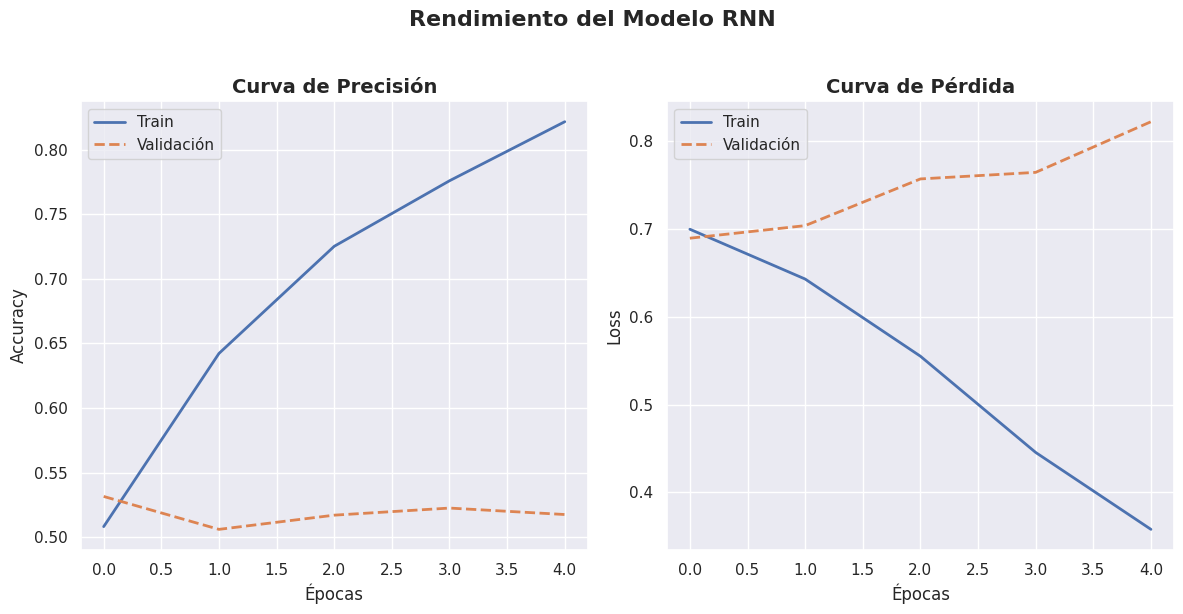

In [58]:
plot_history(history)

LSTM Model


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    # capa de Embedding
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    # capa de LSTM
    # return_sequences=False devuelve solo la última salida (para clasificación)
    LSTM(128, return_sequences=False),
    # Capa de Dropout: apaga aleatoriamente el 50% de las neuronas para evitar overfitting
    Dropout(0.5),
    # Capa de salida para clasificación binaria
    Dense(1, activation='sigmoid')
])

# Compilamos
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

* LSTM Model Training


In [60]:
history_lstm = model_lstm.fit(
    # datos de entrenamiento
    X_train_rnn,
    # etiquetas de entrenamiento
    y_train_rnn,
    # numero de epocas de entrenamiento
    epochs=5,
    # tamaño del lote de los datos por cada paso del entrenamiento.
    batch_size=32,
    # datos de validacion
    # esta linea permite verificar como el modelo esta generalizando a los nuevos datos obtenidos
    validation_data=(X_test_rnn, y_test_rnn)
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 68s 252ms/step - accuracy: 0.5345 - loss: 0.6909 - val_accuracy: 0.5585 - val_loss: 0.6842
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.7406 - loss: 0.5591 - val_accuracy: 0.7735 - val_loss: 0.5259
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 76s 227ms/step - accuracy: 0.8572 - loss: 0.3911 - val_accuracy: 0.8285 - val_loss: 0.4357
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 71s 185ms/step - accuracy: 0.8719 - loss: 0.3578 - val_accuracy: 0.8260 - val_loss: 0.4602
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 217ms/step - accuracy: 0.8307 - loss: 0.3819 - val_accuracy: 0.7650 - val_loss: 0.5300


In [61]:
# resumen del modelo que nos dara detalles sobre cada capa y el numero de
# parametros entrenables en el modelo.
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (32, 100, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (32, 128)              │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,216,837 (8.46 MB)

 Trainable params: 738,945 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,477,892 (5.64 MB)

In [62]:
# evaluacion del modelo
loss_lstm, accuracy_lstm = model_lstm.evaluate(X_test_rnn, y_test_rnn)

# impresion de los resultados
print(f'Loss / Perdida del test: {loss_lstm}')
print(f'Accuracy / Precisión {accuracy_lstm}')


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.7650 - loss: 0.5300
Loss / Perdida del test: 0.5299715399742126
Accuracy / Precisión 0.7649999856948853


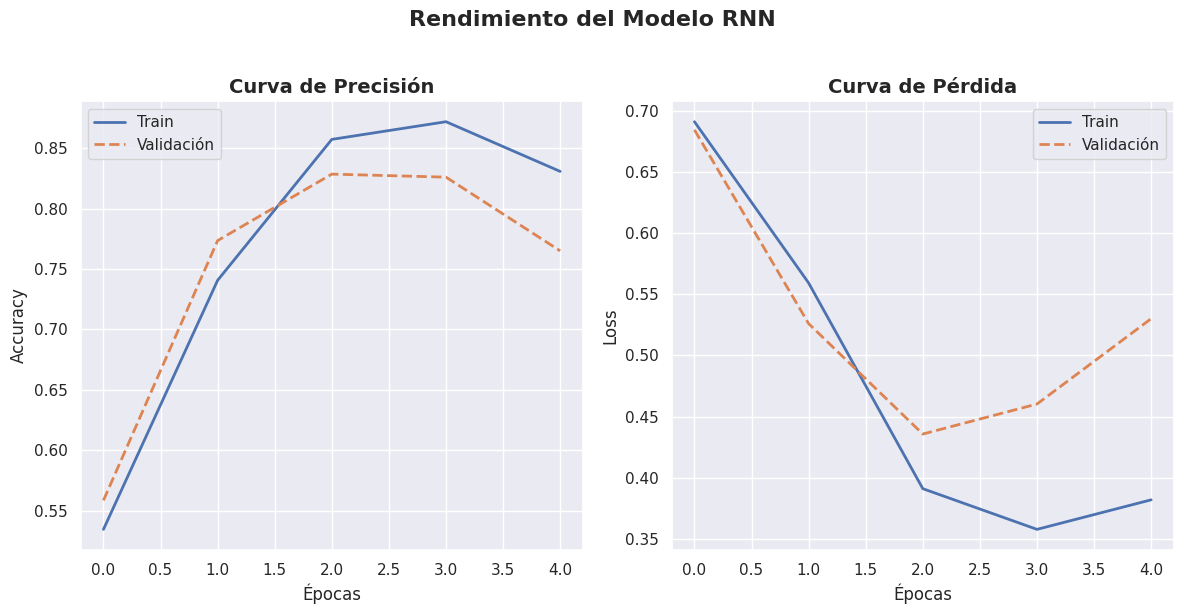

In [63]:
plot_history(history_lstm) # ploteamos loss y accuracy

GRU Model


In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

model_GRU = Sequential([
    # capa de Embedding
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    # capa de GRU con 128 neuronas
    # return_sequences=False devuelve solo la última salida (para clasificación)
    GRU(128, return_sequences=False),
    # Capa de Dropout: apaga aleatoriamente el 50% de las neuronas para evitar overfitting
    Dropout(0.5),
    # Capa de densa (fully connected) con 64 neuronas y activacion de ReLu
    Dense(64, activation='relu'),
    # Capa de salida de 1 sola neurona para clasificación binaria
    Dense(1, activation='sigmoid')
])

# Compilamos
model_GRU.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

* GRU Model Training


In [65]:
# entrenamiento
history_GRU = model_GRU.fit(
    # datos de entrenamiento
    X_train_rnn,
    # etiquetas de entrenamiento
    y_train_rnn,
    # numero de epocas de entrenamiento
    epochs=5,
    # tamaño del lote de los datos por cada paso del entrenamiento.
    batch_size=32,
    # datos de validacion
    # esta linea permite verificar como el modelo esta generalizando a los nuevos datos obtenidos
    validation_data=(X_test_rnn, y_test_rnn)
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 190ms/step - accuracy: 0.5424 - loss: 0.6896 - val_accuracy: 0.7015 - val_loss: 0.5748
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 202ms/step - accuracy: 0.8241 - loss: 0.4045 - val_accuracy: 0.8295 - val_loss: 0.3634
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 211ms/step - accuracy: 0.9356 - loss: 0.1832 - val_accuracy: 0.8470 - val_loss: 0.3821
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 86s 228ms/step - accuracy: 0.9754 - loss: 0.0800 - val_accuracy: 0.8405 - val_loss: 0.5087
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 151ms/step - accuracy: 0.9896 - loss: 0.0357 - val_accuracy: 0.8260 - val_loss: 0.6634


In [66]:
# resumen del modelo que nos dara detalles sobre cada capa y el numero de
# parametros entrenables en el modelo.
model_GRU.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (32, 100, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (32, 128)              │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,453 (8.27 MB)

 Trainable params: 722,817 (2.76 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,445,636 (5.51 MB)

In [67]:
# evaluacion del modelo
loss_GRU, accuracy_GRU = model_lstm.evaluate(X_test_rnn, y_test_rnn)

# impresion de los resultados
print(f'Loss / Perdida del test: {loss_GRU}')
print(f'Accuracy / Precisión {accuracy_GRU}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.7650 - loss: 0.5300
Loss / Perdida del test: 0.5299715399742126
Accuracy / Precisión 0.7649999856948853


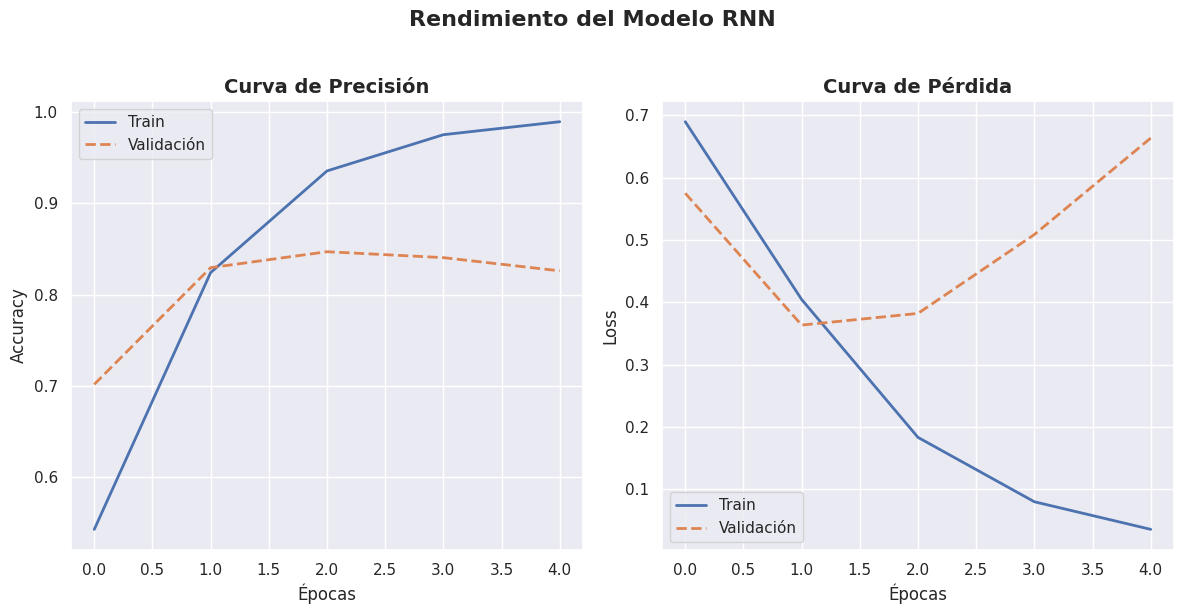

In [68]:
plot_history(history_GRU) # ploteamos loss y accuracy

In [69]:
# Creamos una lista de diccionarios con los resultados de cada modelo
resultados = [
    {'Modelo': 'RNN',   'Loss': loss_rnn,   'Accuracy': accuracy_rnn},
    {'Modelo': 'LSTM',  'Loss': loss_lstm,  'Accuracy': accuracy_lstm},
    {'Modelo': 'GRU',   'Loss': loss_GRU,   'Accuracy': accuracy_GRU}
]

# Convertimos la lista de diccionarios en un DataFrame
df_resultados = pd.DataFrame(resultados)

# Mostramos el DataFrame
print(df_resultados)

  Modelo      Loss  Accuracy
0    RNN  0.821719    0.5175
1   LSTM  0.529972    0.7650
2    GRU  0.529972    0.7650


Regarding the metrics of the different models, we can see that the RNN was one of the worst models analyzed — practically comparable to flipping a coin, with a probability close to 50/50 and a loss of 82%, which is quite alarming.

The models that really stood out within the recurrent neural network group were LSTM and GRU (Accuracy: 76%, Loss: 52%). Although they did not achieve metrics as impressive as the classical ML models, they are not far behind what is expected from such models on a medium-sized dataset.

Both achieved exactly the same performance, but GRU stood out for its speed and lower computational cost, which is also an important factor in this type of analysis.

Therefore, of the 3 Recurrent Neural Network models, in order of efficiency:

* Rank #1: GRU (Gated Recurrent Unit)
* Rank #2: LSTM (Long Short-Term Memory)
* Rank #3: RNN (Recurrent Neural Network)

In terms of efficiency among the neural network architectures.


# TextClassifier PyTorch + Early Stopping
Up to this point in the project we used classical Machine Learning models such as Logistic Regression and SVM, and recurrent architectures such as RNN, LSTM, and GRU with TensorFlow/Keras. In this section we incorporate PyTorch as an alternative framework to implement a fully connected (dense) neural network oriented toward text classification.

Unlike recurrent networks that process text sequentially word by word, this model receives TF-IDF vectors directly as input, making it simpler and faster to train while maintaining good metrics.

The TextClassifier architecture consists of:
- 2 dense layers (nn.Linear)
- Batch Normalization after each layer to stabilize training
- Dropout p=0.5 to reduce overfitting
- CrossEntropyLoss as the loss function

Early Stopping with a patience of 5 epochs was also implemented, monitoring the validation loss. This allows the training to stop automatically when the model stops improving, avoiding overfitting and reducing unnecessary computational cost.


In [89]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ─── 1. Vectorización con TF-IDF (reutilizamos los datos ya procesados) ───
tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True)
X_vec = tfidf.fit_transform(features['token']).toarray()
y_vec = features['sentiment_map'].values

# Split
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_vec, y_vec, test_size=0.2, random_state=42, stratify=y_vec
)

# Tensores
X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_tr_t  = torch.tensor(y_tr,  dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64)

# ─── 2. Arquitectura TextClassifier ───────────────────────────────────────
class TextClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            # Capa densa 1
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            # Capa densa 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            # Capa de salida
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ─── 3. Early Stopping ────────────────────────────────────────────────────
class EarlyStopping:
    """Detiene el entrenamiento si val_loss no mejora en `patience` épocas."""
    def __init__(self, patience=5):
        self.patience  = patience
        self.best_loss = float('inf')
        self.counter   = 0
        self.stop      = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            print(f"  EarlyStopping: sin mejora {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True

# ─── 4. Entrenamiento ─────────────────────────────────────────────────────
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_pt  = TextClassifier(input_dim=X_tr.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
es        = EarlyStopping(patience=5)

for epoch in range(1, 51):   # hasta 50 épocas, pero ES puede frenar antes
    # — train —
    model_pt.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_pt(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # — validation —
    model_pt.eval()
    val_loss = 0
    correct  = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out      = model_pt(xb)
            val_loss += criterion(out, yb).item()
            correct  += (out.argmax(1) == yb).sum().item()

    val_loss /= len(val_loader)
    val_acc   = correct / len(X_val)
    print(f"Época {epoch:3d} | train_loss: {train_loss/len(train_loader):.4f} "
          f"| val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    es.step(val_loss)
    if es.stop:
        print(f"\n⏹ Early Stopping activado en época {epoch}.")
        break

# ─── 5. Evaluación final ──────────────────────────────────────────────────
from sklearn.metrics import classification_report, accuracy_score

model_pt.eval()
with torch.no_grad():
    preds_pt = model_pt(X_val_t.to(device)).argmax(1).cpu().numpy()

print(f"\nAccuracy PyTorch: {accuracy_score(y_val, preds_pt):.4f}")
print(classification_report(y_val, preds_pt, target_names=['Negativo','Positivo']))

Época   1 | train_loss: 0.4318 | val_loss: 0.3288 | val_acc: 0.8540
Época   2 | train_loss: 0.2066 | val_loss: 0.3673 | val_acc: 0.8445
  EarlyStopping: sin mejora 1/5
Época   3 | train_loss: 0.1024 | val_loss: 0.4802 | val_acc: 0.8340
  EarlyStopping: sin mejora 2/5
Época   4 | train_loss: 0.0657 | val_loss: 0.5843 | val_acc: 0.8335
  EarlyStopping: sin mejora 3/5
Época   5 | train_loss: 0.0507 | val_loss: 0.6179 | val_acc: 0.8310
  EarlyStopping: sin mejora 4/5
Época   6 | train_loss: 0.0358 | val_loss: 0.6955 | val_acc: 0.8265
  EarlyStopping: sin mejora 5/5

⏹ Early Stopping activado en época 6.

Accuracy PyTorch: 0.8265
              precision    recall  f1-score   support

    Negativo       0.85      0.80      0.82      1016
    Positivo       0.81      0.85      0.83       984

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



The TextClassifier model implemented in PyTorch proved to be a solid and efficient alternative compared to the recurrent architectures analyzed earlier.

Unlike RNN, LSTM, and GRU which process text sequentially, this model works directly on TF-IDF vectors, which considerably reduces computational cost without sacrificing performance.

Batch Normalization was key to stabilizing training, as it normalizes the activations between layers preventing gradients from exploding or vanishing. Dropout p=0.5 acted as a regularizer by randomly disabling neurons at each step, forcing the model not to depend on any single neuron and generalizing better.

Regarding Early Stopping, it proved to be a very useful tool since it allowed the training to stop automatically when the validation loss stopped improving for 5 consecutive epochs, avoiding overfitting and saving unnecessary computation time.

Compared to the previous models, TextClassifier demonstrated that a well-regularized dense neural network can compete with more complex architectures, serving as an intermediate option between classical Machine Learning models and recurrent networks.


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


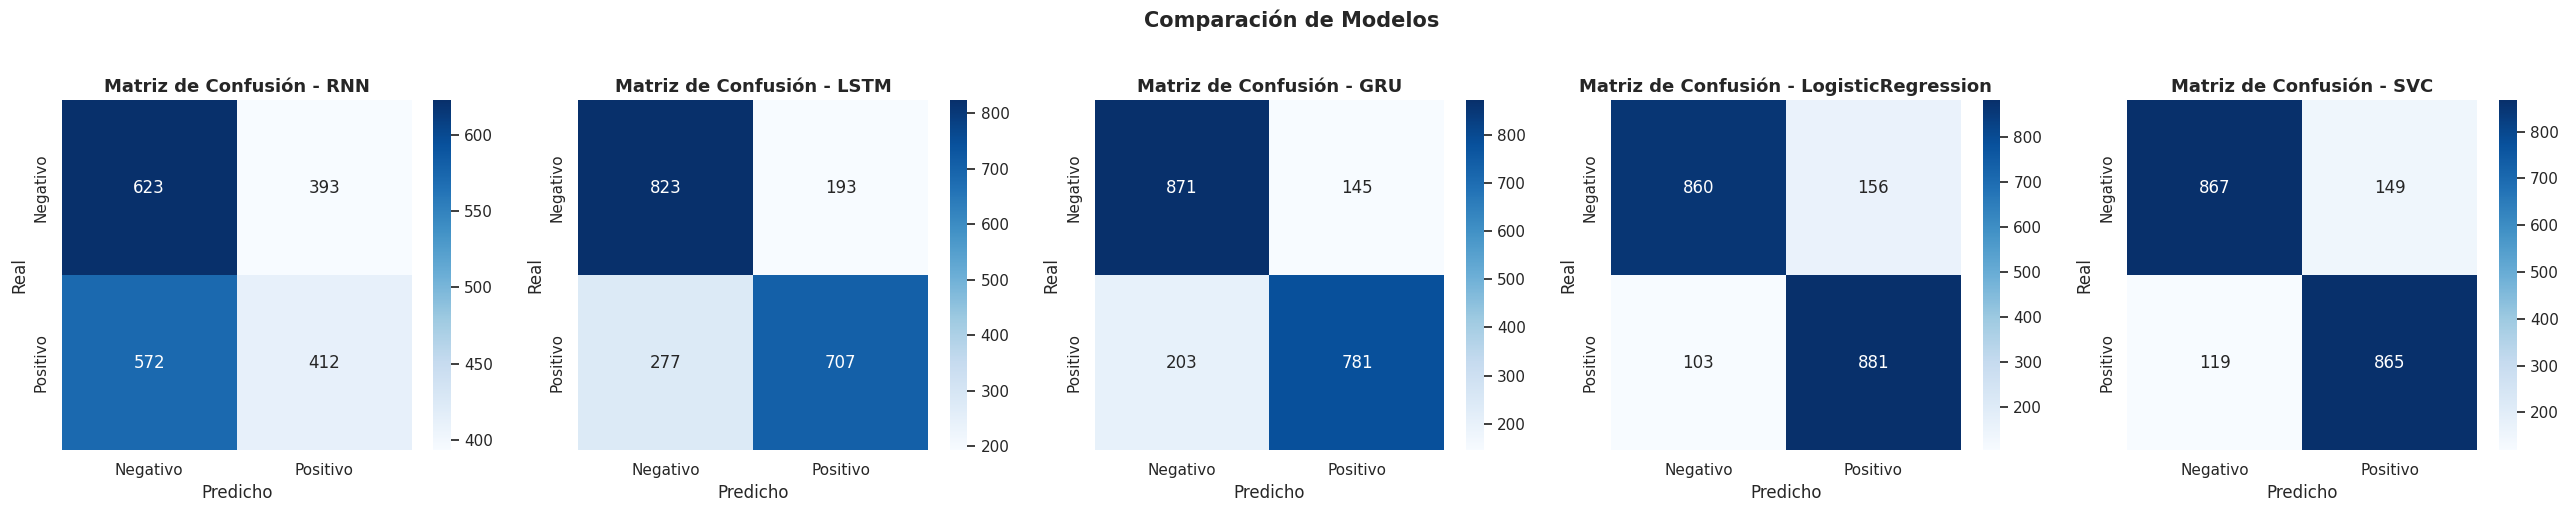

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predicciones
y_pred_rnn  = (model_rnn.predict(X_test_rnn)   > 0.5).astype(int)
y_pred_lstm = (model_lstm.predict(X_test_rnn)  > 0.5).astype(int)
y_pred_gru  = (model_GRU.predict(X_test_rnn)   > 0.5).astype(int)
y_pred_tfidf = (model.predict(x_test)   > 0.5).astype(int)
y_pred_svm  = (model_f.predict(x_test_svm)   > 0.5).astype(int)
# Matrices
cm_rnn  = confusion_matrix(y_test_rnn, y_pred_rnn)
cm_lstm = confusion_matrix(y_test_rnn, y_pred_lstm)
cm_gru  = confusion_matrix(y_test_rnn, y_pred_gru)
cm_lr = confusion_matrix(y_test, y_pred_tfidf)
cm_svm = confusion_matrix(y_test_svm, y_pred_svm)
# Plot
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 5, figsize=(26, 5))

modelos = [('RNN',  cm_rnn), ('LSTM', cm_lstm), ('GRU',  cm_gru), ('LogisticRegression',cm_lr),('SVC',cm_svm)]

for ax, (nombre, cm) in zip(axes, modelos):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Negativo', 'Positivo'],
        yticklabels=['Negativo', 'Positivo'],
        ax=ax
    )
    ax.set_title(f'Matriz de Confusión - {nombre}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Comparación de Modelos', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [83]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# Definimos los modelos con sus predicciones y test
modelos = [
    ('RNN',                y_test_rnn, y_pred_rnn),
    ('LSTM',               y_test_rnn, y_pred_lstm),
    ('GRU',                y_test_rnn, y_pred_gru),
    ('LogisticRegression', y_test,     y_pred_tfidf),
    ('SVC',                y_test_svm, y_pred_svm),
]

# Construimos la tabla de métricas
resultados = []
for nombre, y_test, y_pred in modelos:
    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
    })

df_resultados = pd.DataFrame(resultados).sort_values('F1-Score', ascending=False)
print(df_resultados.to_string(index=False))

            Modelo  Accuracy  Precision  Recall  F1-Score
               SVC    0.8660     0.8531  0.8791    0.8659
LogisticRegression    0.8597     0.8375  0.8869    0.8615
               GRU    0.8260     0.8434  0.7937    0.8178
              LSTM    0.7650     0.7856  0.7185    0.7505
               RNN    0.5175     0.5118  0.4187    0.4606


# General Conclusion
In conclusion, throughout this project five models were implemented and compared for sentiment analysis, combining classical Machine Learning techniques with Deep Learning architectures. The results demonstrated that good data preparation and manipulation is just as important as the model itself, as it was key to achieving the metrics obtained.

Classical models such as SVM and Logistic Regression demonstrated that simplicity can sometimes yield better results, outperforming neural networks on a medium-sized dataset. GRU proved to be the best option among the recurrent neural networks, with a good balance of performance and computational efficiency.

The key takeaway is that the most complex model is not always the best — the right model depends on the problem at hand. Perhaps with a larger dataset or pre-trained embeddings such as GloVe or BERT, neural networks could surpass the classical models.

As an improvement proposal for the neural network models, I would suggest applying GloVe or BERT at the embedding layer to maximize results and see whether these architectures can better assimilate the data and surpass the traditional Machine Learning models.


Project developed by:

Lautaro Rodriguez
